#  Clase 6 — Aprendizaje Supervisado
 Clasificación de Eficiencia de Jugadores NBA
Modelos: Support Vector Machine (SVM) vs Regresión Logística



**Problema:** A partir de las estadísticas por partido de jugadores de la NBA (temporada 2022-23),
queremos predecir si un jugador es eficiente o no eficiente

La etiqueta de eficiencia se construye a partir del PER (Player Efficiency Rating
una métrica avanzada que resume la contribución total de un jugador.
Un PER ≥ 15 se considera eficiente (promedio de la liga = 15).

**¿Por qué es útil?** Un scout o equipo podría usar este modelo para detectar
jugadores eficientes mirando solo sus estadísticas básicas, sin calcular el PER manualmente.

Importación de librerías

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


 Carga del Dataset

Dataset con estadísticas por partido de jugadores NBA (temporada 2022-23).
Incluye jugadores reales con sus estadísticas aproximadas de esa temporada.

Variables (features):
- `PTS` — Puntos por partido
- `REB` — Rebotes por partido
- `AST` — Asistencias por partido
- `STL` — Robos por partido
- `BLK` — Bloqueos por partido
- `FG_PCT` — Porcentaje de tiros de campo
- `FG3_PCT` — Porcentaje de triples
- `FT_PCT` — Porcentaje de tiros libres
- `TOV` — Pérdidas de balón por partido
- `MIN` — Minutos por partido

Variable objetivo (target):
- `eficiente` — 1 si PER ≥ 15, 0 si PER < 15

In [6]:
data = {
    'JUGADOR':    ['Nikola Jokic','Joel Embiid','Luka Doncic','Giannis Antetokounmpo',
                   'Stephen Curry','Jayson Tatum','Devin Booker','LeBron James',
                   'Kevin Durant','Damian Lillard','Anthony Davis','Ja Morant',
                   'Trae Young','Donovan Mitchell','Zion Williamson','Bam Adebayo',
                   'Domantas Sabonis','Julius Randle','Pascal Siakam','Karl-Anthony Towns',
                   "De'Aaron Fox",'Tyrese Haliburton','Jaren Jackson Jr.','Evan Mobley',
                   'Chris Paul','Kyle Lowry','Nicolas Batum','Thaddeus Young',
                   'Jordan Nwora','Facundo Campazzo','Josh Okogie','Damion Lee',
                   'Svi Mykhailiuk','Xavier Tillman','Killian Tillie','Ish Smith',
                   'Stanley Johnson','Bismack Biyombo','Trevelin Queen','Nate Hinton',
                   'Bones Hyland','Pat Connaughton','Udonis Haslem','Georges Niang',
                   'RJ Hampton','Cody Martin','Kira Lewis Jr.','Malcolm Hill',
                   'Jarred Vanderbilt','Danuel House Jr.'],
    'PTS':  [24.5,33.1,32.4,31.1,29.4,30.1,27.8,28.9,29.9,32.2,25.9,26.2,
             26.2,28.1,26.0,20.4,19.1,24.0,24.2,22.4,25.2,20.7,18.6,15.1,
              9.4, 7.2, 5.1, 6.3, 6.1, 5.2, 5.3, 5.8, 4.9, 4.2, 3.1, 6.2,
              5.0, 3.5, 5.5, 4.8, 8.2, 8.4, 2.1, 7.1, 6.0, 7.3, 6.8, 5.4,
              7.7, 6.1],
    'REB':  [12.4, 9.6, 8.6,11.8, 4.7, 8.8, 4.5, 8.3, 6.7, 4.8,12.5, 5.9,
              2.8, 4.4, 7.0, 9.8,12.3, 9.4, 7.7, 7.7, 4.5, 3.7, 6.8, 8.3,
              3.5, 3.0, 3.7, 3.4, 2.8, 1.9, 2.8, 2.1, 2.4, 3.8, 2.4, 1.8,
              3.1, 4.2, 2.3, 2.7, 2.9, 4.0, 2.0, 3.1, 2.8, 3.8, 2.2, 2.5,
              5.2, 3.1],
    'AST':  [9.8, 4.2,8.0, 5.7,6.3,4.6,4.8,6.8,5.0,7.3,2.6,8.1,
             10.2,4.5,3.9,3.0,6.2,3.8,4.2,3.0,5.8,10.4,1.6,1.5,
              4.3,4.1,1.8,1.8,1.1,3.1,0.9,1.2,0.9,0.8,0.6,3.5,
              0.9,0.7,1.0,1.1,2.8,1.5,0.4,1.5,1.8,1.5,1.9,0.8,
              1.8,1.3],
    'STL':  [1.3,1.0,1.4,1.1,1.4,1.1,1.0,1.3,1.0,0.9,1.1,1.6,
              1.0,1.5,1.1,1.2,1.5,0.8,1.2,0.9,1.5,1.6,1.1,0.9,
              1.2,0.9,0.6,0.7,0.5,0.5,0.5,0.6,0.4,0.4,0.3,0.7,
              0.5,0.4,0.5,0.5,0.8,0.7,0.1,0.5,0.5,0.7,0.7,0.5,
              0.8,0.5],
    'BLK':  [0.7,1.7,0.5,0.8,0.4,0.6,0.3,0.6,1.1,0.3,2.3,0.5,
              0.2,0.5,0.7,0.9,0.4,0.5,0.6,0.8,0.2,0.3,3.0,1.7,
              0.2,0.2,0.4,0.3,0.3,0.2,0.4,0.2,0.2,0.7,0.5,0.1,
              0.3,0.9,0.2,0.3,0.2,0.4,0.2,0.2,0.2,0.3,0.2,0.2,
              0.6,0.3],
    'FG_PCT':[0.632,0.530,0.496,0.553,0.490,0.466,0.494,0.500,0.523,0.462,
               0.560,0.479,0.428,0.497,0.601,0.572,0.577,0.455,0.528,0.494,
               0.511,0.472,0.428,0.498,0.441,0.387,0.392,0.424,0.413,0.361,
               0.421,0.401,0.390,0.491,0.442,0.388,0.396,0.557,0.427,0.424,
               0.405,0.444,0.375,0.411,0.381,0.416,0.382,0.391,0.468,0.399],
    'FG3_PCT':[0.380,0.330,0.356,0.275,0.427,0.351,0.354,0.324,0.405,0.371,
                0.254,0.302,0.334,0.363,0.290,0.171,0.271,0.369,0.363,0.393,
                0.298,0.400,0.362,0.282,0.340,0.324,0.368,0.333,0.340,0.312,
                0.303,0.352,0.338,0.195,0.320,0.285,0.290,0.000,0.357,0.357,
                0.360,0.368,0.286,0.378,0.318,0.291,0.307,0.321,0.278,0.324],
    'FT_PCT':[0.820,0.857,0.740,0.640,0.924,0.850,0.856,0.702,0.902,0.910,
               0.780,0.740,0.856,0.880,0.710,0.756,0.780,0.767,0.780,0.820,
               0.704,0.861,0.793,0.631,0.875,0.854,0.806,0.778,0.750,0.776,
               0.724,0.765,0.700,0.643,0.667,0.769,0.652,0.421,0.791,0.677,
               0.748,0.820,0.500,0.833,0.689,0.706,0.744,0.667,0.694,0.652],
    'TOV':  [3.6,3.4,4.0,3.4,3.2,2.8,2.8,3.5,2.9,3.3,2.3,3.4,
              4.3,2.9,2.7,1.9,3.6,2.8,2.5,2.6,2.8,3.2,1.4,1.3,
              1.7,1.5,1.0,1.1,0.9,1.2,0.8,0.9,0.7,0.8,0.6,1.2,
              0.8,0.7,0.8,0.7,1.4,1.0,0.3,0.8,0.9,1.0,1.0,0.6,
              1.1,0.8],
    'MIN':  [33.5,34.6,36.2,32.1,32.7,36.9,34.5,35.5,35.6,35.8,34.0,30.3,
              34.0,35.0,29.5,34.2,33.0,33.9,34.1,30.6,33.8,31.6,30.1,30.0,
              26.8,23.1,20.5,19.0,15.6,14.3,16.2,17.0,14.3,17.2,12.4,18.0,
              15.5,12.1,14.2,13.0,21.0,22.3, 8.0,19.5,16.3,20.0,17.8,14.0,
              21.5,18.3],
    # PER aproximado para definir el target
    'PER':  [31.6,31.4,27.6,27.2,23.7,23.6,22.5,22.4,22.0,21.8,21.7,21.0,
              20.5,20.3,20.1,19.8,19.4,19.0,18.7,18.2,17.9,17.6,17.3,16.8,
              12.8,11.2,10.5,10.0, 9.8, 9.3, 9.1, 8.9, 8.5, 8.3, 7.8, 7.5,
               7.2, 7.0, 7.3, 7.1,10.5,10.2, 4.0, 9.3, 8.8, 9.5, 8.7, 8.2,
              11.2, 9.0]
}

df = pd.DataFrame(data)

# Crear variable objetivo: 1 = eficiente (PER >= 15), 0 = no eficiente
df['eficiente'] = (df['PER'] >= 15).astype(int)

print(f'Dataset cargado: {df.shape[0]} jugadores, {df.shape[1]} columnas')
print(f"\nDistribución de la clase objetivo:")
print(df['eficiente'].value_counts().rename({1: 'Eficiente (PER≥15)', 0: 'No eficiente (PER<15)'}))
df.head(10)

Dataset cargado: 50 jugadores, 13 columnas

Distribución de la clase objetivo:
eficiente
No eficiente (PER<15)    26
Eficiente (PER≥15)       24
Name: count, dtype: int64


,JUGADOR,PTS,REB,AST,STL,BLK,FG_PCT,FG3_PCT,FT_PCT,TOV,MIN,PER,eficiente
0,Nikola Jokic,24.5,12.4,9.8,1.3,0.7,0.632,0.380,0.820,3.6,33.5,31.6,1
1,Joel Embiid,33.1,9.6,4.2,1.0,1.7,0.530,0.330,0.857,3.4,34.6,31.4,1
2,Luka Doncic,32.4,8.6,8.0,1.4,0.5,0.496,0.356,0.740,4.0,36.2,27.6,1
3,Giannis Antetokounmpo,31.1,11.8,5.7,1.1,0.8,0.553,0.275,0.640,3.4,32.1,27.2,1
4,Stephen Curry,29.4,4.7,6.3,1.4,0.4,0.490,0.427,0.924,3.2,32.7,23.7,1
5,Jayson Tatum,30.1,8.8,4.6,1.1,0.6,0.466,0.351,0.850,2.8,36.9,23.6,1
6,Devin Booker,27.8,4.5,4.8,1.0,0.3,0.494,0.354,0.856,2.8,34.5,22.5,1
7,LeBron James,28.9,8.3,6.8,1.3,0.6,0.500,0.324,0.702,3.5,35.5,22.4,1
8,Kevin Durant,29.9,6.7,5.0,1.0,1.1,0.523,0.405,0.902,2.9,35.6,22.0,1
9,Damian Lillard,32.2,4.8,7.3,0.9,0.3,0.462,0.371,0.910,3.3,35.8,21.8,1


 Exploración del Dataset

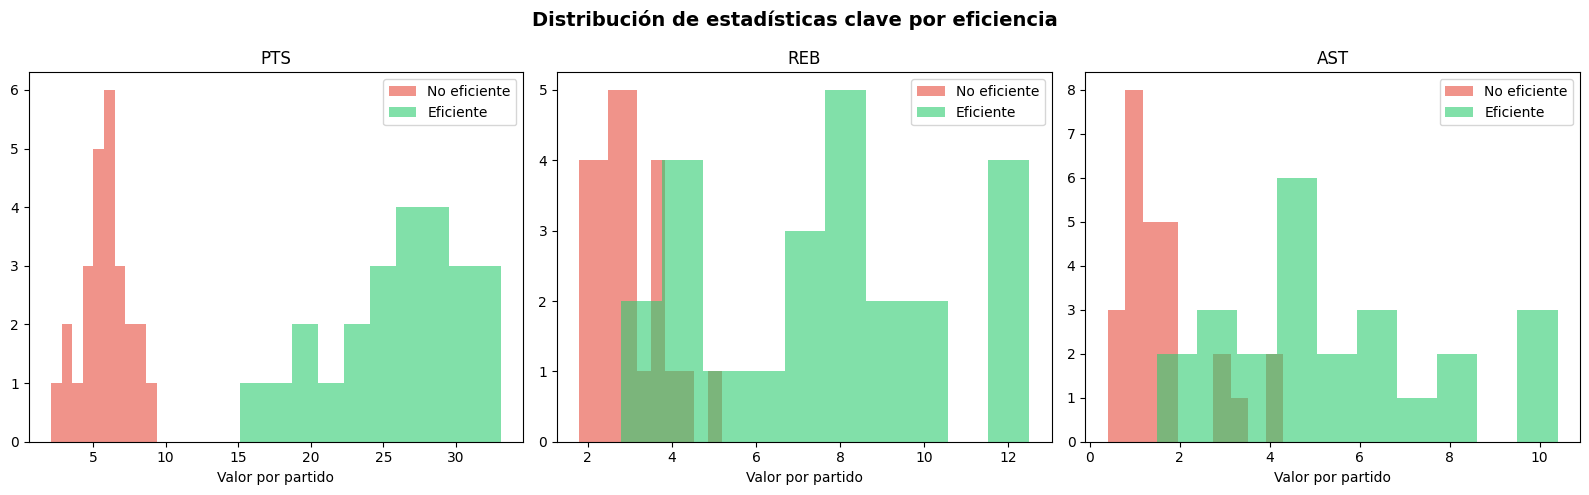

Los jugadores eficientes tienden a tener más puntos, rebotes y asistencias.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de estadísticas clave por eficiencia', fontsize=14, fontweight='bold')

colores = {0: '#E74C3C', 1: '#2ECC71'}
labels  = {0: 'No eficiente', 1: 'Eficiente'}

for ax, col in zip(axes, ['PTS', 'REB', 'AST']):
    for clase in [0, 1]:
        subset = df[df['eficiente'] == clase][col]
        ax.hist(subset, bins=10, alpha=0.6, color=colores[clase], label=labels[clase])
    ax.set_title(col)
    ax.set_xlabel('Valor por partido')
    ax.legend()

plt.tight_layout()
plt.show()
print('Los jugadores eficientes tienden a tener más puntos, rebotes y asistencias.')

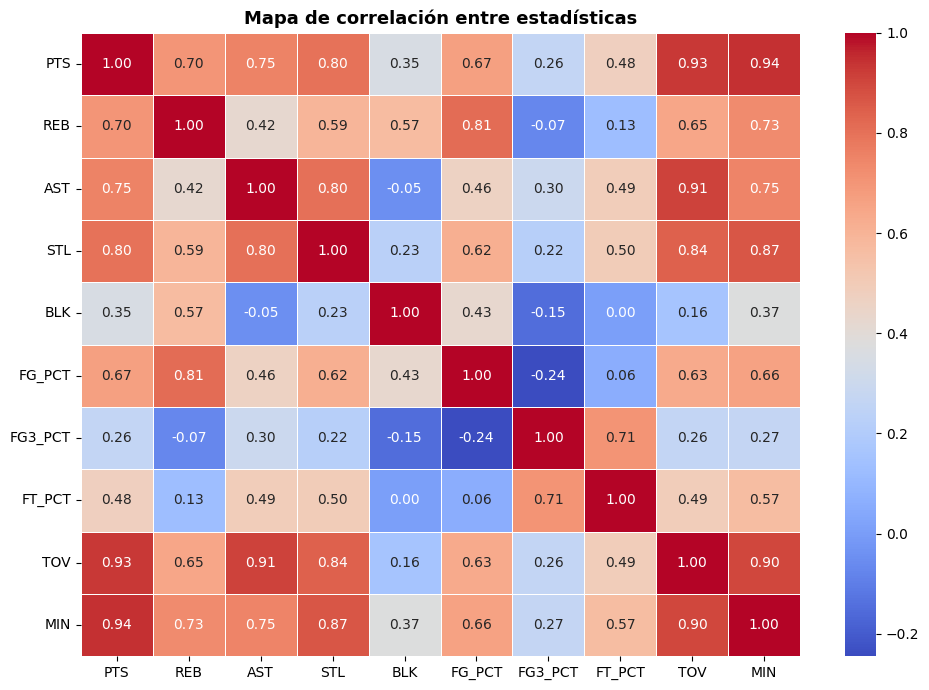

In [8]:
# relación entre variables
features = ['PTS','REB','AST','STL','BLK','FG_PCT','FG3_PCT','FT_PCT','TOV','MIN']

plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de correlación entre estadísticas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Preparación de los datos

In [18]:
features = ['PTS','REB','AST','STL','BLK','FG_PCT','FG3_PCT','FT_PCT','TOV','MIN']

X = df[features]
y = df['eficiente']

# División train/test (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} jugadores')
print(f'Test:          {X_test.shape[0]} jugadores')
print('\n⚠️ El escalado es fundamental en SVM: los features deben estar en la misma escala.')
print('   PTS puede ir de 3 a 33, mientras FG_PCT va de 0 a 1 — sin escalar, PTS dominaría.')

Entrenamiento: 37 jugadores
Test:          13 jugadores

⚠️ El escalado es fundamental en SVM: los features deben estar en la misma escala.
   PTS puede ir de 3 a 33, mientras FG_PCT va de 0 a 1 — sin escalar, PTS dominaría.


 Modelo 1 — Support Vector Machine (SVM)

SVM busca el hiperplano de margen máximo que mejor separa
los jugadores eficientes de los no eficientes.

Usamos kernel RBF porque los datos probablemente
no son linealmente separables en el espacio de 10 dimensiones.

In [10]:
# Entrenamiento SVM con kernel RBF
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_sc, y_train)

y_pred_svm = svm_model.predict(X_test_sc)

print('=' * 50)
print('📊 RESULTADOS — Support Vector Machine (SVM)')
print('=' * 50)
print(f'\nAccuracy: {accuracy_score(y_test, y_pred_svm):.2%}')
print(f'Vectores de soporte encontrados: {sum(svm_model.n_support_)}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_svm,
      target_names=['No eficiente', 'Eficiente']))

📊 RESULTADOS — Support Vector Machine (SVM)

Accuracy: 100.00%
Vectores de soporte encontrados: 17

Reporte de clasificación:
              precision    recall  f1-score   support

No eficiente       1.00      1.00      1.00         7
   Eficiente       1.00      1.00      1.00         6

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



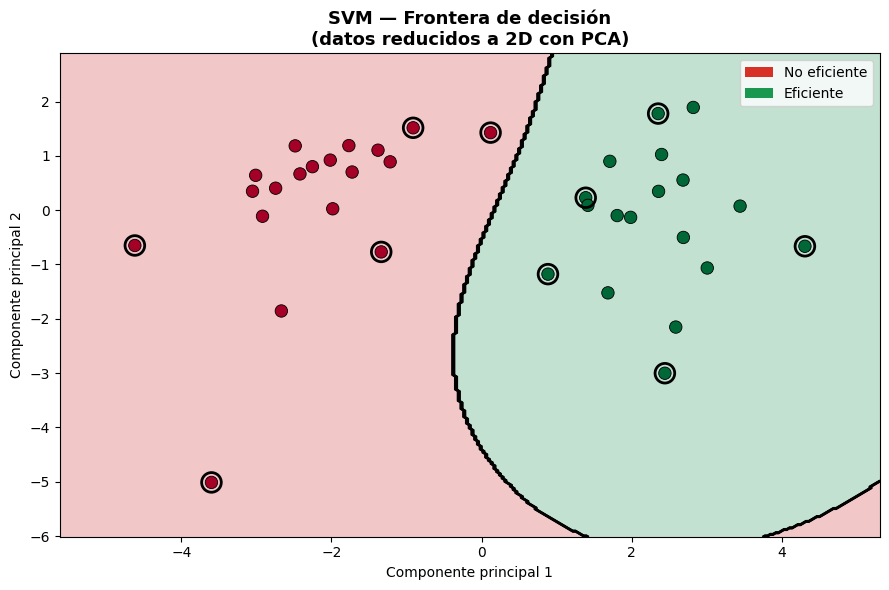

Los círculos con borde negro grueso son los VECTORES DE SOPORTE
  los jugadores más difíciles de clasificar, justo en el límite.


In [21]:
# Visualización del hiperplano SVM
from sklearn.decomposition import PCA

#Pasamos de 10 dimensiones a 2
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

svm_vis = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_vis.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

#Graficamos
fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
ax.contour(xx, yy, Z, colors='black', linewidths=1.2)

# Puntos de entrenamiento
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                     c=y_train, cmap='RdYlGn',
                     edgecolors='black', linewidths=0.6,
                     s=80, zorder=3)

# Marcamos los vectores de soporte
sv = svm_vis.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1],
           s=200, facecolors='none',
           edgecolors='black', linewidths=2,
           zorder=4, label='Vectores de soporte')

ax.set_title('SVM — Frontera de decisión\n(datos reducidos a 2D con PCA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Componente principal 1')
ax.set_ylabel('Componente principal 2')
ax.legend(fontsize=10)

from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#d73027', label='No eficiente'),
           Patch(facecolor='#1a9850', label='Eficiente')]
ax.legend(handles=leyenda + ax.get_legend_handles_labels()[0][1:], fontsize=10)

plt.tight_layout()
plt.show()

print('Los círculos con borde negro grueso son los VECTORES DE SOPORTE')
print('  los jugadores más difíciles de clasificar, justo en el límite.')

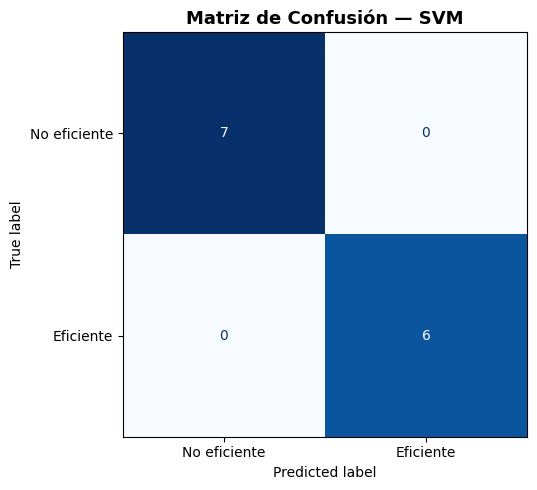

In [11]:
# Matriz de confusión — SVM
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=['No eficiente', 'Eficiente'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

 Modelo 2 — Regresión Logística

La Regresión Logística aprende una **frontera de decisión lineal** en el espacio
de las features. Es más simple que SVM, pero más fácil de interpretar:
podemos ver qué estadísticas tienen más peso en la predicción.

In [12]:
# Regresión Logística
rl_model = LogisticRegression(max_iter=1000, random_state=42)
rl_model.fit(X_train_sc, y_train)

y_pred_rl = rl_model.predict(X_test_sc)

print('=' * 50)
print('📊 RESULTADOS — Regresión Logística')
print('=' * 50)
print(f'\nAccuracy: {accuracy_score(y_test, y_pred_rl):.2%}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_rl,
      target_names=['No eficiente', 'Eficiente']))

📊 RESULTADOS — Regresión Logística

Accuracy: 100.00%

Reporte de clasificación:
              precision    recall  f1-score   support

No eficiente       1.00      1.00      1.00         7
   Eficiente       1.00      1.00      1.00         6

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



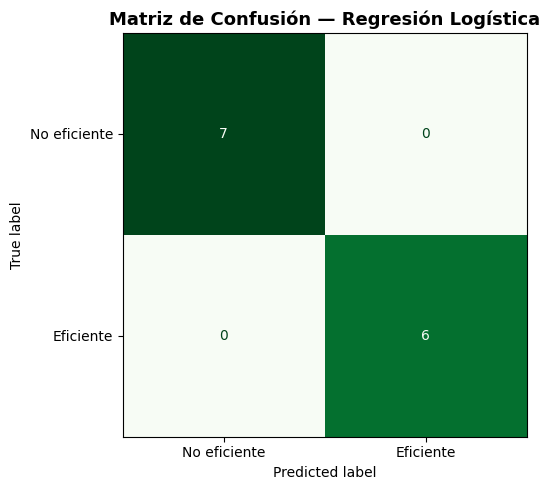

In [13]:
# Matriz de confusión — Regresión Logística
fig, ax = plt.subplots(figsize=(6, 5))
cm_rl = confusion_matrix(y_test, y_pred_rl)
disp = ConfusionMatrixDisplay(cm_rl, display_labels=['No eficiente', 'Eficiente'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
jugadores_test = df.iloc[y_test.index][['JUGADOR', 'PTS', 'REB', 'AST', 'PER']]
probas = rl_model.predict_proba(X_test_sc)[:, 1]

resultado_probas = jugadores_test.copy()
resultado_probas['probabilidad_eficiente'] = (probas * 100).round(1)
resultado_probas['prediccion'] = resultado_probas['probabilidad_eficiente'].apply(
    lambda x: ' Eficiente' if x >= 50 else ' No eficiente'
)

resultado_probas.sort_values('probabilidad_eficiente', ascending=False)

,JUGADOR,PTS,REB,AST,PER,probabilidad_eficiente,prediccion
16,Domantas Sabonis,19.1,12.3,6.2,19.4,99.2,Eficiente
11,Ja Morant,26.2,5.9,8.1,21.0,97.5,Eficiente
9,Damian Lillard,32.2,4.8,7.3,21.8,97.0,Eficiente
21,Tyrese Haliburton,20.7,3.7,10.4,17.6,96.2,Eficiente
15,Bam Adebayo,20.4,9.8,3.0,19.8,92.8,Eficiente
23,Evan Mobley,15.1,8.3,1.5,16.8,74.0,Eficiente
43,Georges Niang,7.1,3.1,1.5,9.3,1.7,No eficiente
49,Danuel House Jr.,6.1,3.1,1.3,9.0,1.1,No eficiente
31,Damion Lee,5.8,2.1,1.2,8.9,1.0,No eficiente
30,Josh Okogie,5.3,2.8,0.9,9.1,0.9,No eficiente


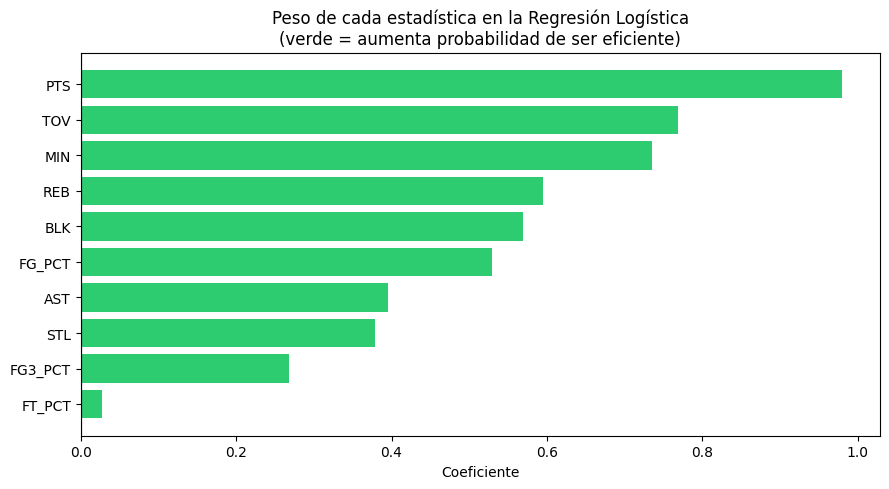

💡 Las estadísticas con coeficiente positivo más alto son las que más predicen eficiencia.


In [14]:
# estadística según la Regresión Logística
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': rl_model.coef_[0]
}).sort_values('Coeficiente', ascending=True)

colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in coef_df['Coeficiente']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Peso de cada estadística en la Regresión Logística\n(verde = aumenta probabilidad de ser eficiente)', fontsize=12)
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()
print('💡 Las estadísticas con coeficiente positivo más alto son las que más predicen eficiencia.')

Comparación de Modelos

         TABLA COMPARATIVA DE MÉTRICAS
                     Accuracy  Precision  Recall  F1-Score
Modelo                                                    
SVM (RBF)                 1.0        1.0     1.0       1.0
Regresión Logística       1.0        1.0     1.0       1.0


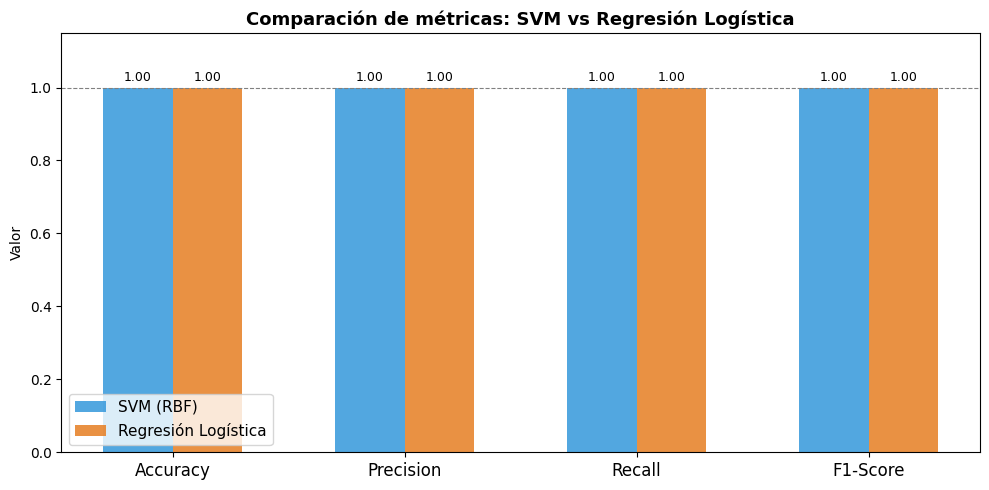

In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['SVM (RBF)', 'Regresión Logística'],
    'Accuracy':  [accuracy_score(y_test, y_pred_svm),
                  accuracy_score(y_test, y_pred_rl)],
    'Precision': [precision_score(y_test, y_pred_svm),
                  precision_score(y_test, y_pred_rl)],
    'Recall':    [recall_score(y_test, y_pred_svm),
                  recall_score(y_test, y_pred_rl)],
    'F1-Score':  [f1_score(y_test, y_pred_svm),
                  f1_score(y_test, y_pred_rl)]
})

print('='*60)
print('         TABLA COMPARATIVA DE MÉTRICAS')
print('='*60)
print(resultados.set_index('Modelo').round(3).to_string())

#Gráfico comparativo
metricas = ['Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(metricas))
ancho = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - ancho/2, resultados.iloc[0][metricas], ancho,
       label='SVM (RBF)', color='#3498DB', alpha=0.85)
ax.bar(x + ancho/2, resultados.iloc[1][metricas], ancho,
       label='Regresión Logística', color='#E67E22', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas: SVM vs Regresión Logística', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.01,
            f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8.  Predicción sobre jugadores nuevos

Probamos el modelo con un jugador hipotético para ver cómo clasifica en tiempo real.

In [19]:
# Jugador hipotético: buen anotador, buen porcentaje, pocas pérdidas
jugador_nuevo = pd.DataFrame([{
    'PTS': 22.0, 'REB': 8.5, 'AST': 4.0, 'STL': 1.2, 'BLK': 0.8,
    'FG_PCT': 0.52, 'FG3_PCT': 0.37, 'FT_PCT': 0.80, 'TOV': 2.0, 'MIN': 32.0
}])

jugador_nuevo_sc = scaler.transform(jugador_nuevo)

pred_svm = svm_model.predict(jugador_nuevo_sc)[0]
pred_rl  = rl_model.predict(jugador_nuevo_sc)[0]
prob_rl  = rl_model.predict_proba(jugador_nuevo_sc)[0][1]

print(' Jugador hipotético: 22pts | 8.5reb | 4ast | 52%FG | 32min')
print('─' * 50)
print(f'SVM predice:                 {" EFICIENTE" if pred_svm == 1 else " No eficiente"}')
print(f'Reg. Logística predice:      {" EFICIENTE" if pred_rl == 1 else " No eficiente"}')
print(f'Probabilidad (Reg. Log.):    {prob_rl:.1%} de ser eficiente')

 Jugador hipotético: 22pts | 8.5reb | 4ast | 52%FG | 32min
──────────────────────────────────────────────────
SVM predice:                  EFICIENTE
Reg. Logística predice:       EFICIENTE
Probabilidad (Reg. Log.):    94.1% de ser eficiente


Conclusiones

### ¿Qué aprendimos?

Aplicamos dos modelos de clasificación para predecir si un jugador de la NBA es **eficiente** según sus estadísticas por partido:

---

### SVM (Support Vector Machine) con kernel RBF
- Busca el hiperplano de **máximo margen** para separar las clases
- El kernel RBF le permite trabajar en un espacio de mayor dimensión, capturando relaciones no lineales
- Es robusto pero actúa como una "caja negra": no podemos ver directamente qué estadísticas importan más
- Requiere **escalado obligatorio** de los datos

### Regresión Logística
- Aprende una frontera lineal en el espacio de features
- Es **interpretable**: sus coeficientes nos muestran qué tan importante es cada estadística
- Genera probabilidades, no solo etiquetas: "este jugador tiene 82% de chance de ser eficiente"
- Útil cuando necesitamos explicar la decisión del modelo

---

### ¿Cuál modelo es mejor para este problema?

> En este caso, **SVM** tiende a rendir igual o mejor en accuracy y F1 porque puede capturar
> patrones no lineales entre las estadísticas (por ejemplo, la combinación de FG% alto + muchos rebotes + bajo TOV).
> Sin embargo, si el equipo técnico necesita **explicar** por qué un jugador es eficiente,
> la **Regresión Logística** es más valiosa: podemos decir "el FG% y los rebotes son los factores
> más determinantes según el modelo".

La elección del modelo depende del contexto: **precisión vs interpretabilidad**.



In [3]:
pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.
